# EDA — CEDEARs Screener

Análisis exploratorio sobre el warehouse `data/warehouse.duckdb` que arma el resto del proyecto:

- **`dim_empresa`** — identidad + sector/industria/país (una fila por empresa)
- **`fact_metrics_daily`** — ratios de valuación y momentum fundamental (una fila por empresa y día — hoy todavía tiene un solo día cargado, así que este notebook lo trata como una foto del momento, no como serie de tiempo)
- **`fact_precios_daily`** — OHLCV diario, 5 años de historia

Objetivo: entender qué hay en los datos antes de construir cualquier score o agente encima — calidad de datos, distribuciones, outliers, y relaciones entre variables (value vs growth, sector vs valuación, etc.).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

dim_empresa = con.execute("SELECT * FROM dim_empresa").fetchdf()
metrics = con.execute("SELECT * FROM fact_metrics_daily").fetchdf()
precios = con.execute("SELECT * FROM fact_precios_daily").fetchdf()

print("dim_empresa:", dim_empresa.shape)
print("fact_metrics_daily:", metrics.shape)
print("fact_precios_daily:", precios.shape)

dim_empresa: (340, 12)
fact_metrics_daily: (340, 28)
fact_precios_daily: (406985, 8)


## 1. Calidad de datos

Antes de analizar nada: cuántos nulls hay por columna. Un campo con muchos nulls no es necesariamente un bug — puede ser una limitación real de la fuente (ej. `eps_growth_5y_pct` casi siempre va a estar vacío porque Yahoo gratis no da 6 años de historia, ver `analisis_fundamental.py`).

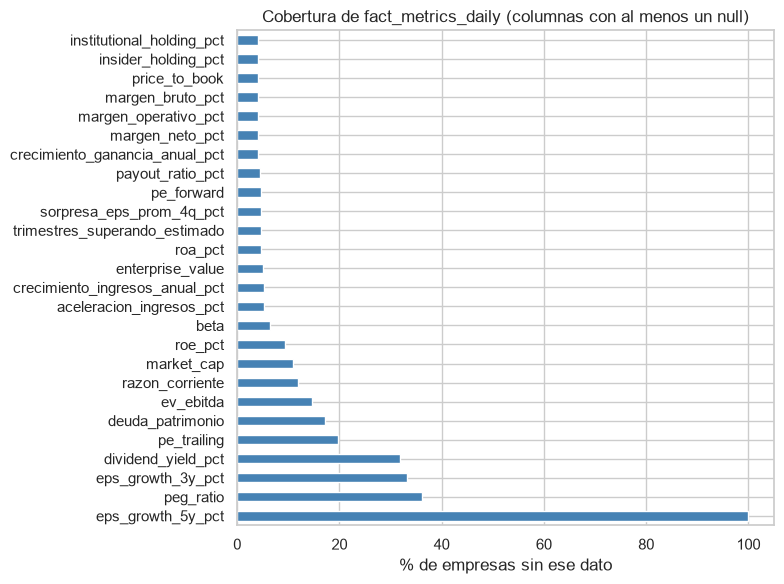

eps_growth_5y_pct                 100.0
peg_ratio                          36.2
eps_growth_3y_pct                  33.2
dividend_yield_pct                 31.8
pe_trailing                        19.7
deuda_patrimonio                   17.1
ev_ebitda                          14.7
razon_corriente                    11.8
market_cap                         10.9
roe_pct                             9.4
beta                                6.5
aceleracion_ingresos_pct            5.3
crecimiento_ingresos_anual_pct      5.3
enterprise_value                    5.0
roa_pct                             4.7
trimestres_superando_estimado       4.7
sorpresa_eps_prom_4q_pct            4.7
pe_forward                          4.7
payout_ratio_pct                    4.4
crecimiento_ganancia_anual_pct      4.1
margen_neto_pct                     4.1
margen_operativo_pct                4.1
margen_bruto_pct                    4.1
price_to_book                       4.1
insider_holding_pct                 4.1


In [2]:
nulls = metrics.isna().mean().sort_values(ascending=False) * 100
nulls = nulls[nulls > 0].round(1)

fig, ax = plt.subplots(figsize=(8, 6))
nulls.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% de empresas sin ese dato")
ax.set_title("Cobertura de fact_metrics_daily (columnas con al menos un null)")
plt.tight_layout()
plt.show()

nulls

## 2. Universo por sector y mercado

`lynch_category` todavía está vacía para las 340 empresas (es la clasificación pendiente que vamos a hacer con ayuda de un LLM). Por ahora, `sector`/`industria` de Yahoo son la única forma de agrupar.

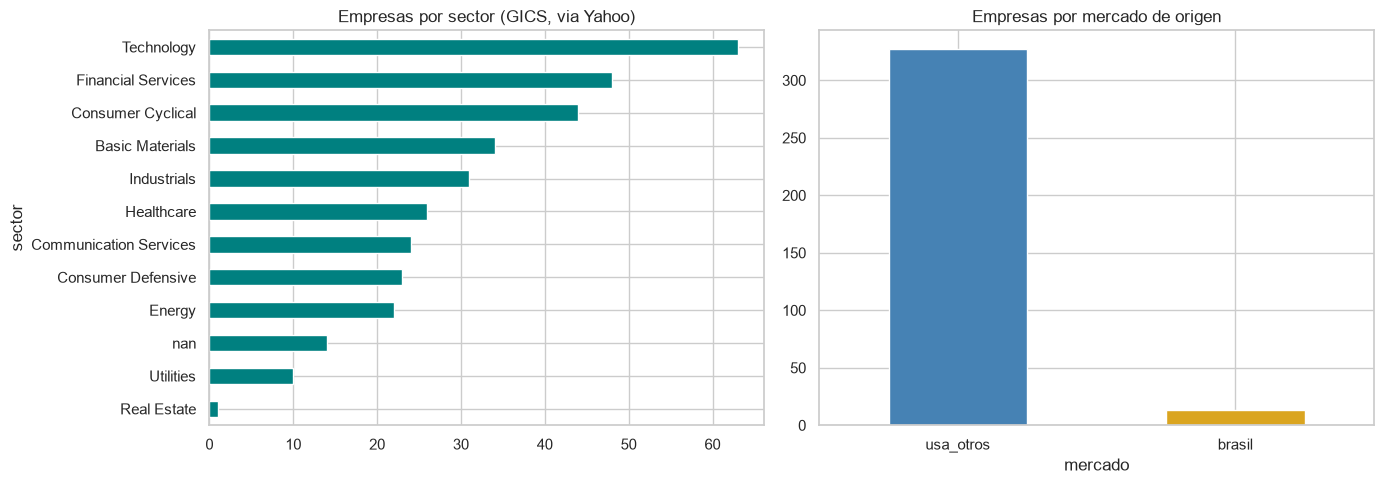

Sin sector clasificado: 0 de 340


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dim_empresa["sector"].value_counts().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Empresas por sector (GICS, via Yahoo)")
axes[0].invert_yaxis()

dim_empresa["mercado"].value_counts().plot(kind="bar", ax=axes[1], color=["steelblue", "goldenrod"])
axes[1].set_title("Empresas por mercado de origen")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(f"Sin sector clasificado: {dim_empresa['sector'].isna().sum()} de {len(dim_empresa)}")

## 3. Distribución de ratios de valuación

Los ratios de valuación tienen outliers extremos por naturaleza (una empresa con ganancia casi cero da un P/E disparatado). Para ver la distribución "típica" recortamos al percentil 1-99 solo para graficar — el dato original en `metrics` queda intacto.

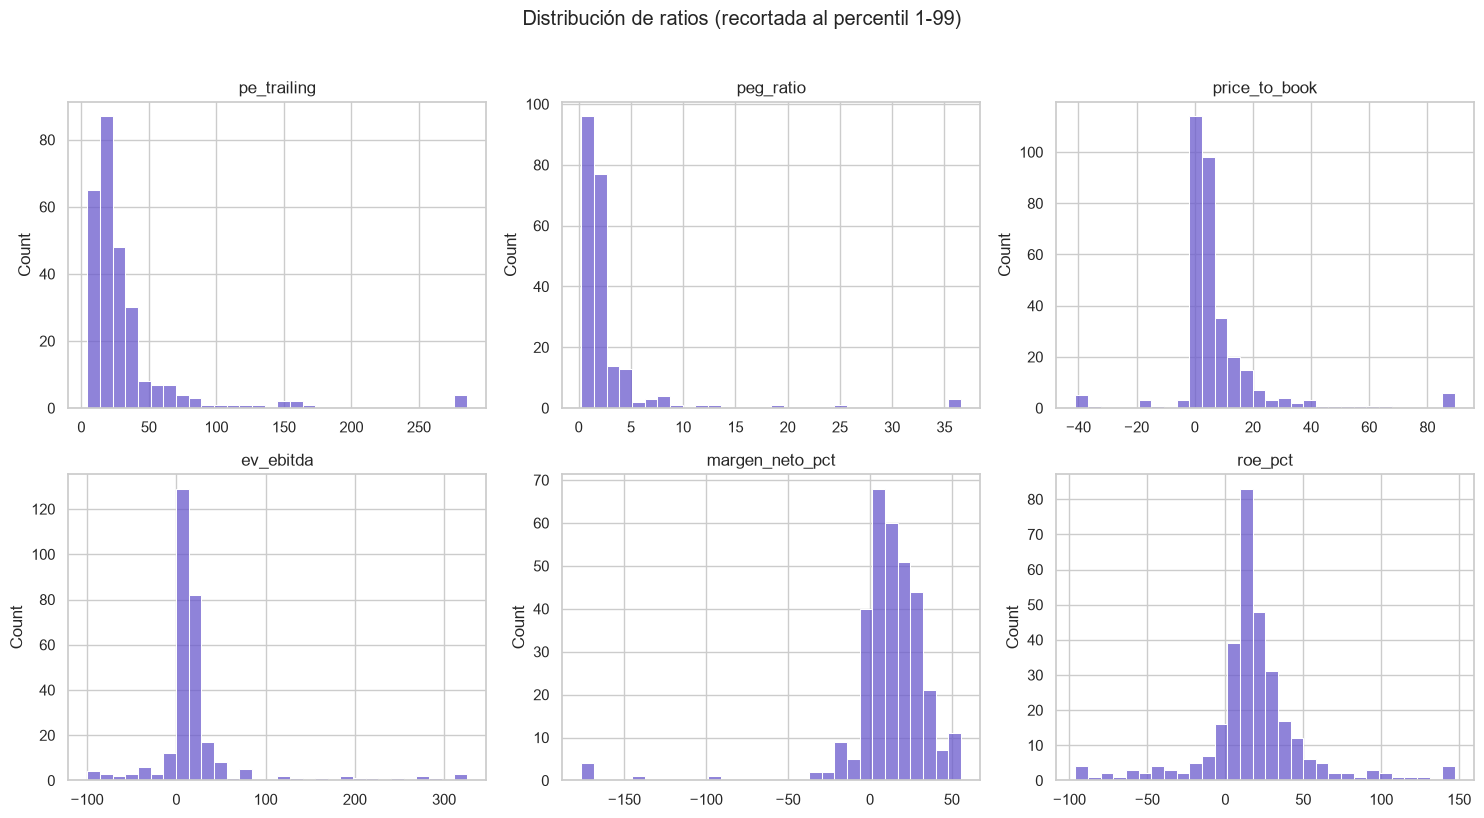

C:\Users\Usuario\guia\cedears-data-pipeline\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,pe_trailing,peg_ratio,price_to_book,ev_ebitda,margen_neto_pct,roe_pct
count,273.00,217.00,326.00,290.00,326.00,308.00
mean,inf,3.31,12.05,40.56,11.34,16.83
std,NaN,9.81,90.87,289.98,30.54,46.54
min,2.76,0.04,-199.36,-728.86,-230.60,-432.30
25%,14.20,1.02,1.62,5.87,4.40,7.15
50%,21.46,1.58,3.28,11.91,11.55,14.85
75%,34.50,2.36,9.08,22.13,25.25,27.35
max,inf,105.18,1563.04,3809.20,96.20,267.40


In [4]:
ratios = ["pe_trailing", "peg_ratio", "price_to_book", "ev_ebitda", "margen_neto_pct", "roe_pct"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ratios):
    serie = metrics[col].dropna()
    lo, hi = serie.quantile([0.01, 0.99])
    sns.histplot(serie.clip(lo, hi), bins=30, ax=ax, color="slateblue")
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Distribución de ratios (recortada al percentil 1-99)", y=1.02)
plt.tight_layout()
plt.show()

metrics[ratios].describe().round(2)

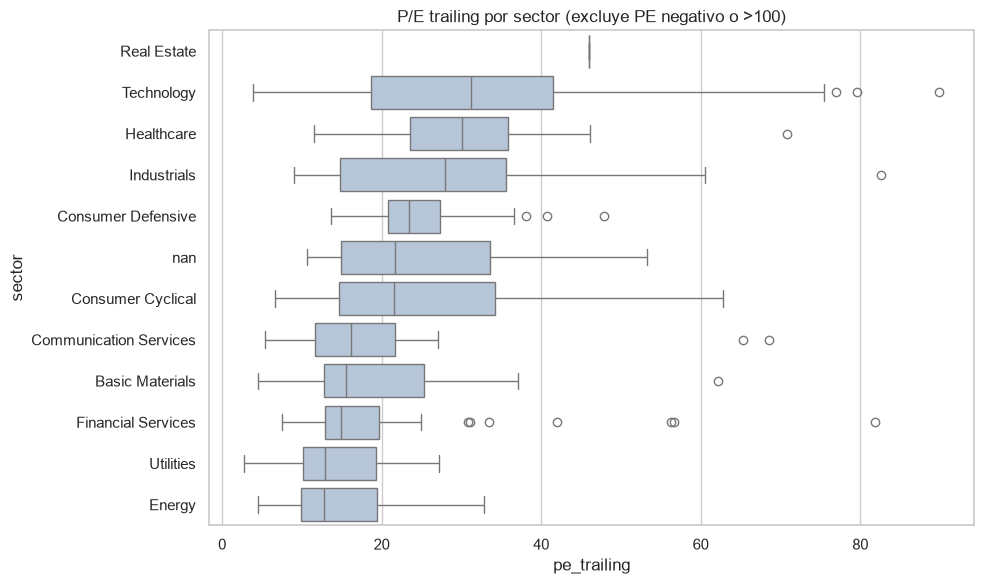

In [5]:
m = metrics.merge(dim_empresa[["ticker_usd", "sector"]], on="ticker_usd")
m_pe = m[(m["pe_trailing"] > 0) & (m["pe_trailing"] < 100) & m["sector"].notna()]  # PE negativo o absurdo no aporta a comparar

orden = m_pe.groupby("sector")["pe_trailing"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=m_pe, y="sector", x="pe_trailing", order=orden, ax=ax, color="lightsteelblue")
ax.set_title("P/E trailing por sector (excluye PE negativo o >100)")
plt.tight_layout()
plt.show()

## 4. Crecimiento y momentum

`crecimiento_ingresos_anual_pct` es el YoY del último balance anual. `aceleracion_ingresos_pct` compara esa tasa contra la anterior: positivo = viene creciendo cada vez más rápido, negativo = viene desacelerando (aunque siga creciendo fuerte, como vimos con NVDA).

In [6]:
crecimiento = metrics.merge(dim_empresa[["ticker_usd", "nombre_empresa", "sector"]], on="ticker_usd")
crecimiento = crecimiento.dropna(subset=["crecimiento_ingresos_anual_pct"])

top15 = crecimiento.nlargest(15, "crecimiento_ingresos_anual_pct")
bottom15 = crecimiento.nsmallest(15, "crecimiento_ingresos_anual_pct")

cols = ["ticker_usd", "nombre_empresa", "sector", "crecimiento_ingresos_anual_pct", "aceleracion_ingresos_pct"]
print("Top 15 crecimiento de ingresos YoY:")
display(top15[cols])
print("\nBottom 15 (mayor caída de ingresos):")
display(bottom15[cols])

Top 15 crecimiento de ingresos YoY:


,ticker_usd,nombre_empresa,sector,crecimiento_ingresos_anual_pct,aceleracion_ingresos_pct
31,ASTS,Ast Spacemobile Inc,Technology,1505.2,1605.2
220,ONDS,Ondas Holdings Inc,Technology,605.3,659.4
201,NBIS,Nebius Group N.V,Communication Services,479.0,-354.7
92,CRWV,Coreweave Inc,Technology,167.9,-568.3
161,IREN,Iren Ltd,Financial Services,167.7,19.7
32,ALAB,Astera Labs Inc,Technology,115.1,-127.1
85,CDE,Coeur D'Alene Mines Cor,Basic Materials,96.4,68.1
337,XPEV,Xpeng Inc,Consumer Cyclical,87.7,54.5
57,BMNR,Bitmine Immersion Technologies Inc,Financial Services,84.1,-328.8
283,TEM,Tempus Ai Inc,Healthcare,83.4,53.0



Bottom 15 (mayor caída de ingresos):


,ticker_usd,nombre_empresa,sector,crecimiento_ingresos_anual_pct,aceleracion_ingresos_pct
326,SPCE,Virgin Galactic Holdings Inc,Industrials,-78.1,-81.5
196,MRNA,Moderna Inc,Healthcare,-39.9,12.7
69,AI,C3.Ai Inc,Technology,-35.7,-60.9
241,RGTI,Rigetti Computing,Technology,-34.3,-24.2
55,BIOX,Bioceres Crop Solutions,Basic Materials,-28.3,-39.1
130,GPRK,Geopark Ltd,Energy,-25.5,-12.8
222,PCAR,Paccar Inc,Industrials,-15.5,-11.3
64,LND,Brasilagro Com,Consumer Defensive,-15.3,-3.0
142,HOG,Harley Davidson Inc,Consumer Cyclical,-13.8,-2.6
101,DE,Deere & Company,Industrials,-11.6,4.6


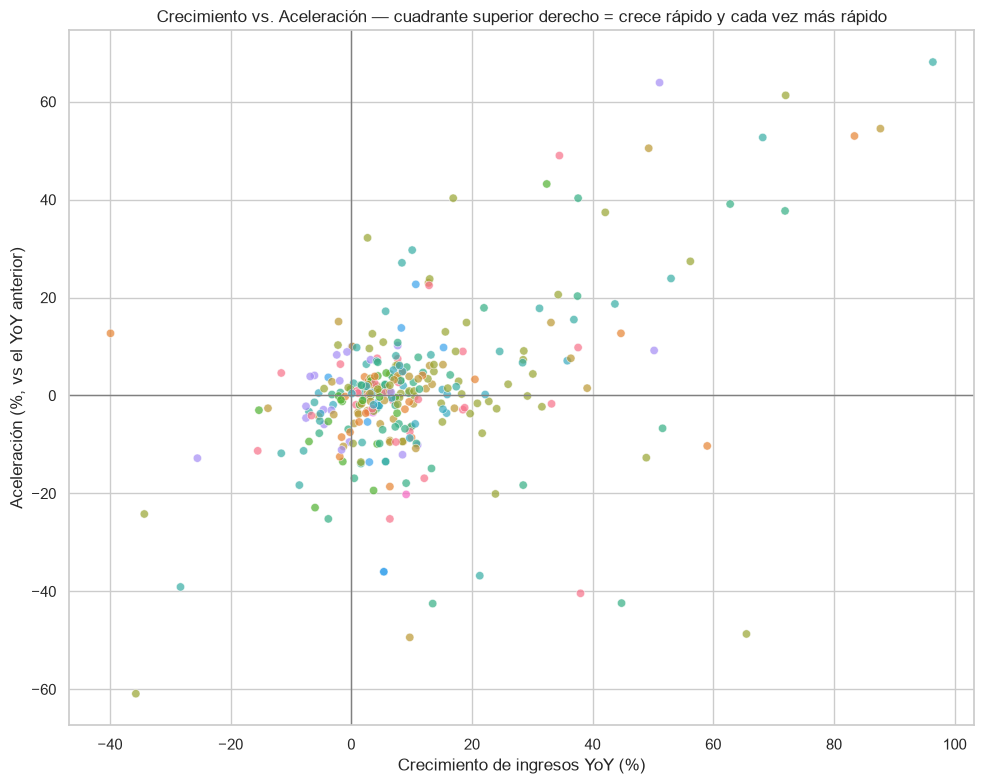

In [7]:
# Recorte para que los outliers extremos (ASTS +1500%, etc.) no aplasten el grafico
c = crecimiento.dropna(subset=["aceleracion_ingresos_pct"])
c = c[c["crecimiento_ingresos_anual_pct"].between(-50, 100) & c["aceleracion_ingresos_pct"].between(-100, 100)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=c, x="crecimiento_ingresos_anual_pct", y="aceleracion_ingresos_pct",
                 hue="sector", alpha=0.7, ax=ax, legend=False)
ax.axhline(0, color="grey", linewidth=1)
ax.axvline(0, color="grey", linewidth=1)
ax.set_xlabel("Crecimiento de ingresos YoY (%)")
ax.set_ylabel("Aceleración (%, vs el YoY anterior)")
ax.set_title("Crecimiento vs. Aceleración — cuadrante superior derecho = crece rápido y cada vez más rápido")
plt.tight_layout()
plt.show()

## 5. Precios y retornos (5 años)

Retorno total usando `adj_close` (ya ajustado por splits/dividendos) entre la primera y la última fecha disponible por ticker.

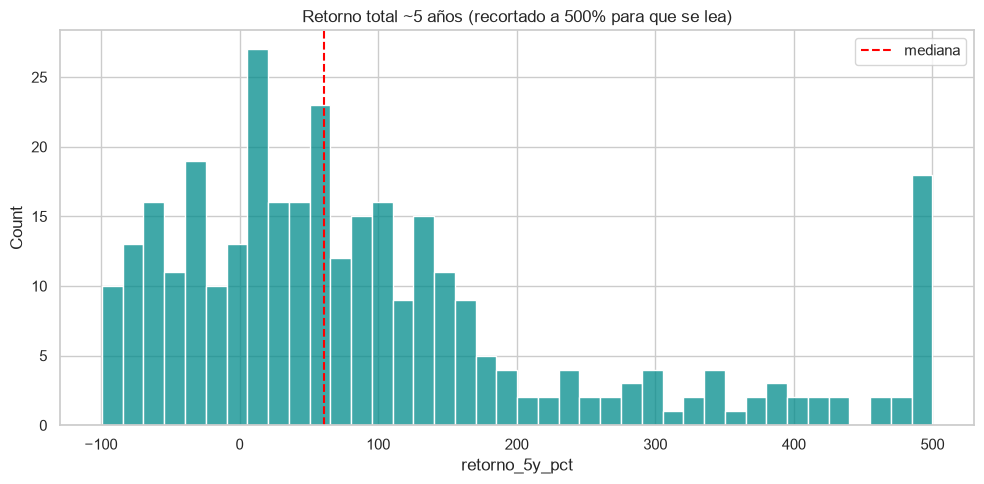

Top 10 retorno 5y:


,ticker_usd,nombre_empresa,retorno_5y_pct
265,SNDK,Sandisk Corporation,4422.311062
72,CLS,Celestica Inc,3900.345474
310,VIST,Vista Oil & Gas Sab De,1326.508714
191,MU,Micron Technology Inc,1273.252055
194,NBIS,Nebius Group N.V,1175.199966
208,NVDA,Nvidia Corporation,1033.229517
32,AVGO,Broadcom Inc,840.201251
315,VST,Vistra Corporation,809.040013
138,HWM,Howmet Aerospace Inc,797.221797
24,ANET,Arista Networks Inc,791.335349



Bottom 10 retorno 5y:


,ticker_usd,nombre_empresa,retorno_5y_pct
268,SPCE,Virgin Galactic Holdings Inc,-99.340703
179,MGLU3,Magazine Luiza S.A,-97.631839
124,HAPV3,Hapvida Participacoes I Investimentos Sa,-97.081977
50,BIOX,Bioceres Crop Solutions,-96.742424
264,SNAP,Snap Inc,-92.517808
256,SDA,Suncar Technology Group,-91.853360
200,NIO,Nio Inc,-88.348006
41,BAK,Braskem Sa,-88.118390
114,GLOB,Globant S.A,-85.138319
305,UPST,Upstart Holdings Inc,-84.523869


In [8]:
precios_ordenado = precios.sort_values(["ticker_usd", "fecha"])
primero = precios_ordenado.groupby("ticker_usd").first()["adj_close"]
ultimo = precios_ordenado.groupby("ticker_usd").last()["adj_close"]

retornos = ((ultimo / primero) - 1) * 100
retornos = retornos.rename("retorno_5y_pct").reset_index()
retornos = retornos.merge(dim_empresa[["ticker_usd", "nombre_empresa", "sector"]], on="ticker_usd")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(retornos["retorno_5y_pct"].clip(-100, 500), bins=40, ax=ax, color="darkcyan")
ax.axvline(retornos["retorno_5y_pct"].median(), color="red", linestyle="--", label="mediana")
ax.set_title("Retorno total ~5 años (recortado a 500% para que se lea)")
ax.legend()
plt.tight_layout()
plt.show()

print("Top 10 retorno 5y:")
display(retornos.nlargest(10, "retorno_5y_pct")[["ticker_usd", "nombre_empresa", "retorno_5y_pct"]])
print("\nBottom 10 retorno 5y:")
display(retornos.nsmallest(10, "retorno_5y_pct")[["ticker_usd", "nombre_empresa", "retorno_5y_pct"]])

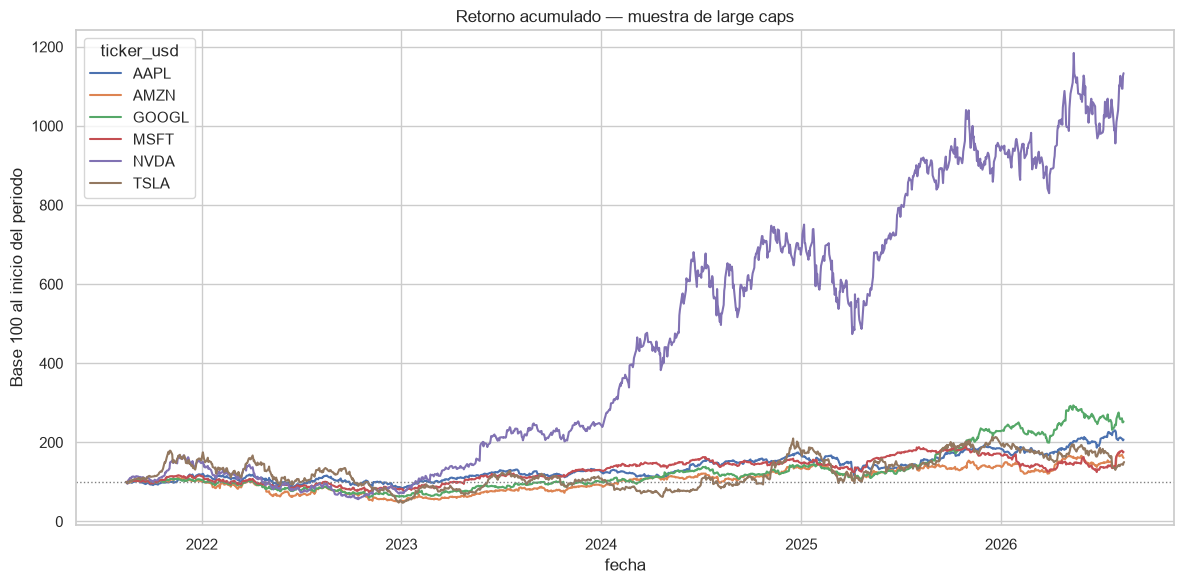

In [9]:
muestra = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "TSLA"]
p = precios[precios["ticker_usd"].isin(muestra)].sort_values(["ticker_usd", "fecha"]).copy()
p["retorno_acumulado"] = p.groupby("ticker_usd")["adj_close"].transform(lambda s: s / s.iloc[0] * 100)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=p, x="fecha", y="retorno_acumulado", hue="ticker_usd", ax=ax)
ax.axhline(100, color="grey", linewidth=1, linestyle=":")
ax.set_ylabel("Base 100 al inicio del periodo")
ax.set_title("Retorno acumulado — muestra de large caps")
plt.tight_layout()
plt.show()

## 6. Value vs Growth

¿Hay empresas creciendo fuerte que el mercado todavía no le puso un P/E alto? Cuadrante inferior derecho = crece mucho y cotiza barata (candidatas a mirar más de cerca).

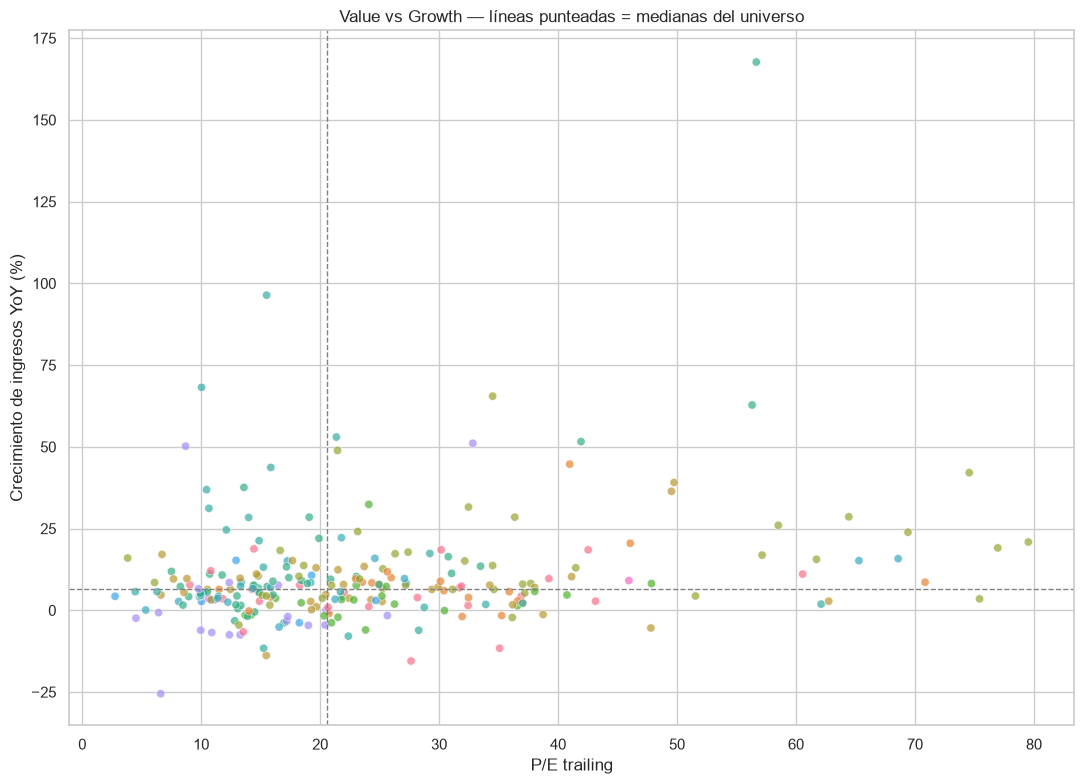

,ticker_usd,nombre_empresa,sector,pe_trailing,crecimiento_ingresos_anual_pct
85,CDE,Coeur D'Alene Mines Cor,Basic Materials,15.50,96.4
135,GFI,Gold Fields Ltd,Basic Materials,10.03,68.2
328,VIST,Vista Oil & Gas Sab De,Energy,8.69,50.2
11,AEM,Agnico Eagle Mines Limi,Basic Materials,15.85,43.7
10,AEG,Aegon N.V. American Reg,Financial Services,13.59,37.6
172,KGC,Kinross Gold Corp,Basic Materials,10.45,36.9
51,B,Barrick Mining Corporation,Basic Materials,10.65,31.2
214,NU,Nu Holdings Ltd/Cayman,Financial Services,19.08,28.5
226,PAAS,Pan American Silver Corp,Basic Materials,13.99,28.4
143,HMY,Harmony Gold Mining Co,Basic Materials,12.11,24.6


In [10]:
vg = metrics.merge(dim_empresa[["ticker_usd", "nombre_empresa", "sector"]], on="ticker_usd")
vg = vg.dropna(subset=["pe_trailing", "crecimiento_ingresos_anual_pct"])
vg = vg[(vg["pe_trailing"] > 0) & (vg["pe_trailing"] < 80)]  # PE negativo/absurdo distorsiona el grafico

mediana_pe = vg["pe_trailing"].median()
mediana_crec = vg["crecimiento_ingresos_anual_pct"].median()

fig, ax = plt.subplots(figsize=(11, 8))
sns.scatterplot(data=vg, x="pe_trailing", y="crecimiento_ingresos_anual_pct", hue="sector", alpha=0.7, ax=ax, legend=False)
ax.axhline(mediana_crec, color="grey", linewidth=1, linestyle="--")
ax.axvline(mediana_pe, color="grey", linewidth=1, linestyle="--")
ax.set_xlabel("P/E trailing")
ax.set_ylabel("Crecimiento de ingresos YoY (%)")
ax.set_title("Value vs Growth — líneas punteadas = medianas del universo")
plt.tight_layout()
plt.show()

# Candidatas: crecen mas que la mediana con PE por debajo de la mediana
candidatas = vg[(vg["crecimiento_ingresos_anual_pct"] > mediana_crec) & (vg["pe_trailing"] < mediana_pe)]
candidatas.sort_values("crecimiento_ingresos_anual_pct", ascending=False)[
    ["ticker_usd", "nombre_empresa", "sector", "pe_trailing", "crecimiento_ingresos_anual_pct"]
].head(20)

## Próximos pasos

- `fact_metrics_daily` hoy es una sola foto — a medida que `analisis_fundamental.py` se corra en más días, va a poder verse evolución real de PE/márgenes/crecimiento por empresa, no solo comparación entre empresas.
- `lynch_category`/`modelo_negocio` siguen pendientes de clasificar (con ayuda de LLM + revisión manual) — una vez cargadas, se puede repetir la Sección 2 agrupando por esas categorías en vez de solo sector.
- Este notebook es la base para los futuros agentes (técnico, fundamental, quant): las mismas queries de acá son las que un agente correría para responder "¿cómo está esta empresa vs. su sector?" en lenguaje natural.